# 📊 E-commerce Sales Analysis
## 📌 Objective
This project focuses on analyzing e-commerce sales data to uncover meaningful insights related to sales performance, customer behavior, and profitability.

The analysis is performed using Python (Pandas & Matplotlib), with the goal of understanding business trends and supporting data-driven decision making.

In [2]:
!pip install pandas
import pandas as pd

## 📥 Data Loading

In this step, the dataset is imported into the environment using Pandas.  
This allows us to begin exploring and analyzing the data efficiently.

In [3]:
df=pd.read_csv("sales_data.csv", encoding='latin-1')

In [4]:
df.head()

,Row ID,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,Segment,Country,City,...,postal_code,Region,product_id,Category,sub_category,product_name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 🔍 Data Exploration

Here, we explore the structure of the dataset including:
- Number of rows and columns
- Data types
- Summary statistics

This helps in understanding the dataset before performing any analysis.

In [5]:
df.shape

(9994, 21)

In [6]:
df.columns

Index(['Row ID', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'Segment', 'Country', 'City', 'State',
       'postal_code', 'Region', 'product_id', 'Category', 'sub_category',
       'product_name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  sub_category   9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.describe()

,Row ID,postal_code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 🧹 Data Cleaning

Data cleaning is an important step to ensure accuracy.

In this section:
- Missing values are identified
- Necessary cleaning steps are applied

Clean data ensures reliable analysis and insights.

In [9]:
df.isnull().sum()

Row ID           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
Segment          0
Country          0
City             0
State            0
postal_code      0
Region           0
product_id       0
Category         0
sub_category     0
product_name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.dropna(inplace=True)

## 📊 Sales Analysis

In this section, we analyze overall sales performance across different dimensions such as region, category, and products.

This helps identify high-performing areas of the business.

In [11]:
df["Sales"].sum()

2297200.8603000003

##🌍 Regional Insight
Sales by Region
In this section, we examine sales across regions to identify top and low-performing areas.

In [12]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

The West region contributes the highest revenue, suggesting better market penetration.

### 🛒 Product Insight
Top 10 Products
In this section, we identify top-selling products that contribute most to revenue.

In [13]:
df.groupby("product_name")["Sales"].sum().sort_values(ascending=False).head(10)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

High-value office equipment contributes the majority of revenue, indicating strong business demand.

##📈 Monthly Sales Trend

In this section, we analyze monthly sales to identify trends and seasonal patterns.

In [14]:
df["order_date"]=pd.to_datetime(df["order_date"], format='mixed', errors='coerce')
df["Month"]=df["order_date"].dt.month
monthly_sales = df.groupby("Month")["Sales"].sum().sort_index()

print(monthly_sales)

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


🌍 Regional Sales Insight

The bar chart shows the distribution of sales across different regions, highlighting performance differences.

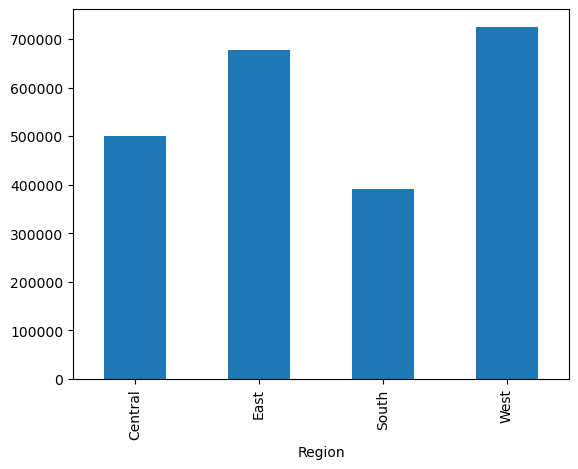

In [15]:
import matplotlib.pyplot as plt

df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.show()

📈 Monthly Sales Insight

Sales peak in November and December, indicating strong seasonal demand during the holiday period.

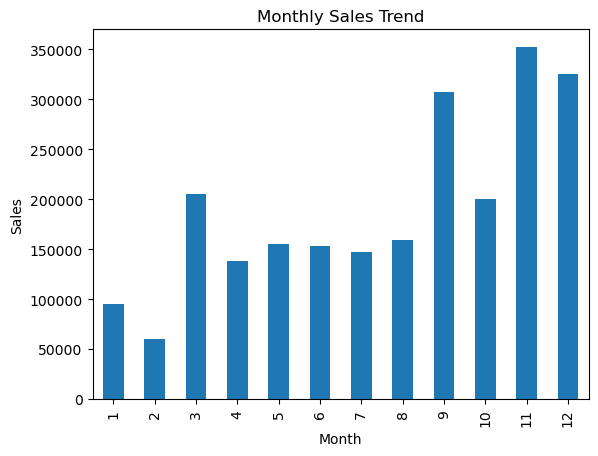

In [16]:
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

📉 Discount vs Profit Insight

The scatter plot shows the relationship between discount and profit, indicating how discounts impact profitability.

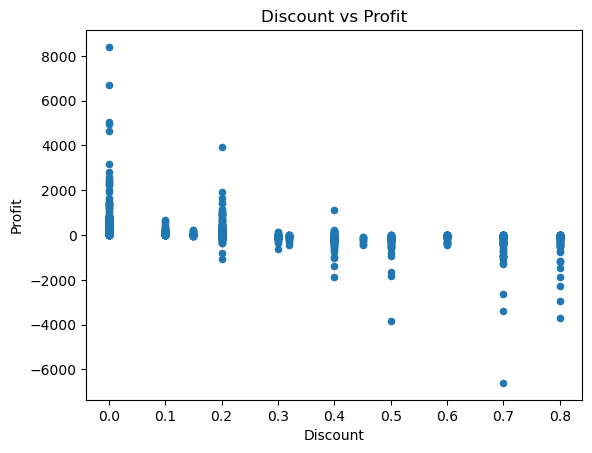

In [17]:
df.plot.scatter(x="Discount", y="Profit")
plt.title("Discount vs Profit")
plt.show()

## 👥 Customer Analysis

This section focuses on understanding customer behavior.

We identify:
- Top customers based on sales
- Contribution of customers to overall revenue

This helps in recognizing valuable customers.

In [19]:
customer_sales = df.groupby("customer_id")["Sales"].sum().sort_values(ascending=False)
customer_sales.head(10)

customer_id
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Sales, dtype: float64

## 💰 Profit Analysis

Here, we analyze profitability across different regions and categories.

This helps in understanding which areas are most profitable for the business.

In [20]:
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [21]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [23]:
df["order_id"].nunique()
df["Sales"].sum() / df["order_id"].nunique()

458.61466566180883

## 📈 Data Visualization

Visualizations are used to better understand patterns and trends in the data.

Charts make it easier to interpret insights compared to raw numbers.

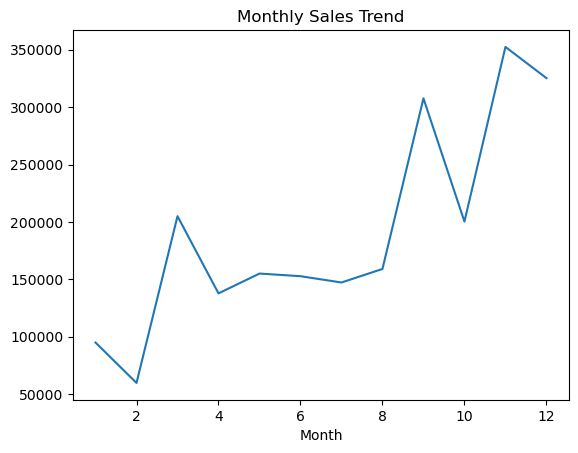

In [24]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["Month"] = df["order_date"].dt.month

df.groupby("Month")["Sales"].sum().plot(kind="line")
plt.title("Monthly Sales Trend")
plt.show()

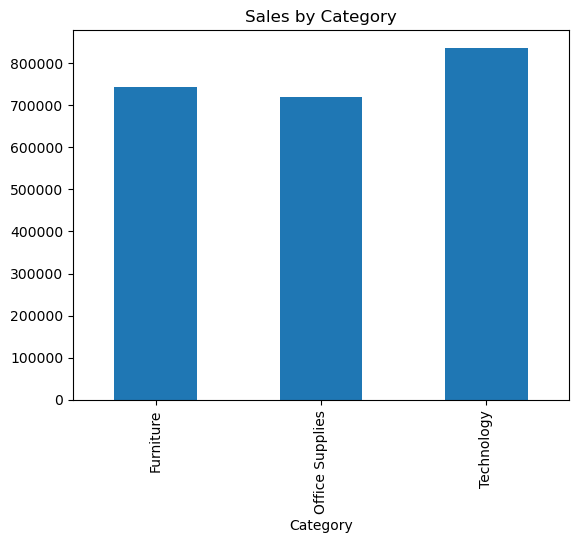

In [25]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.show()

## 📊 Final Insights

- Top 10 customers contribute a significant portion of revenue
- West region is the most profitable
- Technology category performs best in terms of sales
- Sales show seasonality across months
- Average Order Value indicates customer purchasing behavior